# BNPL — Merchant 3-Month GMV Forecast (13 Weeks)

**Goal:** Forecast each merchant’s next 13 weeks of **gross merchandise value (GMV)** from historical transactions, validate on a held-out future 13-week period, and export `predicted_3m_revenue` for merchant ranking.

**Method:** Global Histogram Gradient Boosting regression on merchant-week historical features. Training labels are the *following* 13 weeks of GMV. Compare with a trailing-13-week baseline. **No random train/test split and no future-derived predictors.**

**Terminology:** `predicted_3m_revenue` is **predicted merchant transaction value (GMV)**, *not* BNPL fee revenue or profit. This forecast assumes the transaction history is representative of the prospective BNPL business; explain that limitation in your presentation.

**Inputs:** `data/curated/curated_transactions/part_2.parquet`, `part_3.parquet`, `part_4.parquet`. **Output:** `data/curated/merchant_features/predicted_3m_revenue.parquet` (separate file; does not overwrite merchant features).

## 1. Dependencies and paths
If necessary, install dependencies in your active notebook environment: `%pip install duckdb scikit-learn pyarrow`

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

ROOT = Path.cwd()
if not (ROOT / 'data' / 'curated' / 'curated_transactions').exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data' / 'curated' / 'curated_transactions'
OUT_DIR = ROOT / 'data' / 'curated' / 'merchant_features'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FILES = [DATA_DIR / f'part_{i}.parquet' for i in (2, 3, 4)]
assert all(p.exists() for p in FILES), f'Missing parquet files: {[str(p) for p in FILES if not p.exists()]}'
HORIZON = 13
SEED = 42
print('Root:', ROOT)
print('Files:', FILES)

Root: /Users/amyliu/Desktop/MAST30034_Project_2
Files: [PosixPath('/Users/amyliu/Desktop/MAST30034_Project_2/data/curated/curated_transactions/part_2.parquet'), PosixPath('/Users/amyliu/Desktop/MAST30034_Project_2/data/curated/curated_transactions/part_3.parquet'), PosixPath('/Users/amyliu/Desktop/MAST30034_Project_2/data/curated/curated_transactions/part_4.parquet')]


## 2. Aggregate transactions into weekly merchant GMV
These steps prevent duplicate transactions and incomplete weeks from distorting our merchant revenue forecasts.

DuckDB reads the Parquet files without loading all raw transactions into pandas. We deduplicate identical `order_id` records using one record per order; conflicting records with the same order ID should be resolved upstream in ETL. Weeks start on Monday. The final incomplete calendar week is excluded to avoid treating a partial week as a full observation.

In [3]:
# Load and aggregate transactions using pandas only

weekly_parts = []
seen_order_ids = set()

for file in FILES:
    print(f"Reading {file.name}...")

    df = pd.read_parquet(file)

    # Support the customer identifier used by the ETL pipeline
    if "user_id" in df.columns and "consumer_id" not in df.columns:
        df = df.rename(columns={"user_id": "consumer_id"})

    required = [
        "order_id",
        "merchant_abn",
        "order_datetime",
        "dollar_value",
        "consumer_id"
    ]

    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"{file.name} is missing columns: {missing}")

    # Remove invalid records
    df["order_datetime"] = pd.to_datetime(
        df["order_datetime"], errors="coerce"
    )
    df["dollar_value"] = pd.to_numeric(
        df["dollar_value"], errors="coerce"
    )

    df = df.dropna(subset=required)
    df = df[np.isfinite(df["dollar_value"])]
    df = df[df["dollar_value"] >= 0].copy()

    # Remove duplicate order IDs across all partitions
    df = df.drop_duplicates(subset=["order_id"])

    keep = ~df["order_id"].isin(seen_order_ids)
    df = df.loc[keep].copy()
    seen_order_ids.update(df["order_id"])

    # Convert transaction dates to the start of their week
    df["week"] = (
        df["order_datetime"]
        .dt.to_period("W-SUN")
        .dt.start_time
    )

    weekly_parts.append(
        df[["merchant_abn", "week", "dollar_value", "consumer_id"]]
    )

# Combine transaction partitions
transactions = pd.concat(weekly_parts, ignore_index=True)

# Aggregate to merchant-week level
weekly = (
    transactions
    .groupby(["merchant_abn", "week"], as_index=False)
    .agg(
        gmv=("dollar_value", "sum"),
        txn_count=("dollar_value", "size"),
        unique_users=("consumer_id", "nunique")
    )
    .sort_values(["merchant_abn", "week"])
    .reset_index(drop=True)
)

assert not weekly.empty, "No weekly data found"

# Exclude the latest potentially incomplete week
last_week = weekly["week"].max()
weekly = weekly.loc[weekly["week"] < last_week].copy()

assert not weekly.empty, "No complete weekly data found"

print("Complete weeks through:", weekly["week"].max().date())
print("Unique merchants:", weekly["merchant_abn"].nunique())
print("Merchant-week observations:", len(weekly))

display(weekly.head())

Reading part_2.parquet...
Reading part_3.parquet...
Reading part_4.parquet...
Complete weeks through: 2022-10-17
Unique merchants: 4422
Merchant-week observations: 298975


,merchant_abn,week,gmv,txn_count,unique_users
0,10023283211,2021-02-22,701.566638,3,3
1,10023283211,2021-03-01,6362.419840,27,27
2,10023283211,2021-03-08,4706.012141,23,23
3,10023283211,2021-03-15,3536.843553,17,17
4,10023283211,2021-03-22,6796.619996,30,30


## 3. Construct a complete weekly panel

how we handle weeks when a merchant has no transactions helping model distinguish between new merchants and existing ones with periods of low sales 

Missing merchant-weeks are represented as **zero sales**. This is important: a missing row does not mean that a merchant had unknown sales. It means no recorded orders in that week. New merchants have no artificial history before their first recorded transaction; tenure is measured from first observed activity.

In [4]:
all_merchants = np.sort(weekly['merchant_abn'].unique())
all_weeks = pd.date_range(weekly['week'].min(), weekly['week'].max(), freq='W-MON')
index = pd.MultiIndex.from_product([all_merchants, all_weeks], names=['merchant_abn','week'])
panel = (weekly.set_index(['merchant_abn','week'])[['gmv','txn_count','unique_users']]
         .reindex(index, fill_value=0).reset_index())
for c in ['gmv','txn_count','unique_users']:
    panel[c] = panel[c].astype('float32')
print('Panel rows:', len(panel), '| weeks:', len(all_weeks), '| merchants:', len(all_merchants))
assert len(all_weeks) >= 45, 'Need >=45 complete weeks for historical windows, training and validation.' 

Panel rows: 384714 | weeks: 87 | merchants: 4422


## 4. Engineer strictly historical predictors and future labels

At prediction week **t**, predictors use observations through t only. The label is GMV in weeks **t+1 through t+13**. No target-derived feature uses any part of the forecast window.

In [5]:
g = panel.groupby('merchant_abn', sort=False)
for window in (4, 8, 13, 26):
    panel[f'gmv_sum_{window}'] = g['gmv'].transform(lambda x: x.rolling(window, min_periods=1).sum()).astype('float32')
for window in (4, 13):
    panel[f'txn_sum_{window}'] = g['txn_count'].transform(lambda x: x.rolling(window, min_periods=1).sum()).astype('float32')
    panel[f'users_mean_{window}'] = g['unique_users'].transform(lambda x: x.rolling(window, min_periods=1).mean()).astype('float32')
panel['gmv_mean_13'] = panel['gmv_sum_13'] / 13.0
panel['gmv_std_13'] = g['gmv'].transform(lambda x: x.rolling(13, min_periods=2).std()).fillna(0).astype('float32')
panel['gmv_lag_1'] = g['gmv'].shift(1).fillna(0).astype('float32')
panel['gmv_lag_13'] = g['gmv'].shift(13).fillna(0).astype('float32')
panel['gmv_trend_4_vs_13'] = (panel['gmv_sum_4'] / 4) / (panel['gmv_sum_13'] / 13 + 1) - 1
panel['active_weeks_13'] = g['gmv'].transform(lambda x: x.gt(0).rolling(13, min_periods=1).sum()).astype('float32')
panel['weeks_observed'] = g.cumcount().astype('float32') + 1
panel['week_of_year'] = panel['week'].dt.isocalendar().week.astype(int)
panel['season_sin'] = np.sin(2*np.pi*panel['week_of_year']/52.18)
panel['season_cos'] = np.cos(2*np.pi*panel['week_of_year']/52.18)
# A direct 13-week future target. All 13 weeks must be present.
future_parts = [g['gmv'].shift(-k) for k in range(1, HORIZON+1)]
panel['target_13w_gmv'] = sum(future_parts)
FEATURES = ['gmv_sum_4','gmv_sum_8','gmv_sum_13','gmv_sum_26',
            'txn_sum_4','txn_sum_13','users_mean_4','users_mean_13',
            'gmv_mean_13','gmv_std_13','gmv_lag_1','gmv_lag_13',
            'gmv_trend_4_vs_13','active_weeks_13','weeks_observed',
            'season_sin','season_cos']
assert panel.loc[panel.week == all_weeks[-1], 'target_13w_gmv'].isna().all()
print('Features:', FEATURES)
print('Target missing (expected for final 13 weeks):', panel.target_13w_gmv.isna().mean().round(3))

Features: ['gmv_sum_4', 'gmv_sum_8', 'gmv_sum_13', 'gmv_sum_26', 'txn_sum_4', 'txn_sum_13', 'users_mean_4', 'users_mean_13', 'gmv_mean_13', 'gmv_std_13', 'gmv_lag_1', 'gmv_lag_13', 'gmv_trend_4_vs_13', 'active_weeks_13', 'weeks_observed', 'season_sin', 'season_cos']
Target missing (expected for final 13 weeks): 0.149


## 5. Honest time-based backtest

Validation cutoff is **13 weeks before the last complete week**. Training examples are cutoffs **at least another 13 weeks earlier**, so their entire outcome window is known by the validation cutoff. We sample training cutoffs every four weeks to reduce overlapping labels and training time. This is a *single holdout*, not proof of generalisation across multiple market regimes.

In [6]:
last_complete_week = all_weeks[-1]
validation_cutoff = all_weeks[-(HORIZON + 1)]
# Require 13 observed weeks before each training cutoff; last training outcome ends by validation cutoff.
training_cutoffs = all_weeks[12 : len(all_weeks)-2*HORIZON : 4]
assert len(training_cutoffs) >= 2, 'Insufficient history for leakage-free 13-week backtest.'
train = panel.loc[panel.week.isin(training_cutoffs) & panel.target_13w_gmv.notna()].copy()
valid = panel.loc[panel.week == validation_cutoff].copy()
assert len(valid) == len(all_merchants)
assert train.week.max() + pd.Timedelta(weeks=HORIZON) <= validation_cutoff
assert valid.target_13w_gmv.notna().all()
print('Train cutoffs:', [d.strftime('%Y-%m-%d') for d in training_cutoffs])
print('Last training target ends:', (train.week.max() + pd.Timedelta(weeks=HORIZON)).date())
print('Validation forecast origin:', validation_cutoff.date())
print('Validation target through:', last_complete_week.date())
print('Training rows:', len(train), 'Validation merchants:', len(valid))

Train cutoffs: ['2021-05-17', '2021-06-14', '2021-07-12', '2021-08-09', '2021-09-06', '2021-10-04', '2021-11-01', '2021-11-29', '2021-12-27', '2022-01-24', '2022-02-21', '2022-03-21', '2022-04-18']
Last training target ends: 2022-07-18
Validation forecast origin: 2022-07-18
Validation target through: 2022-10-17
Training rows: 57486 Validation merchants: 4422


## 6. Fit the model and compare against a simple baseline

In [7]:
def make_model():
    return HistGradientBoostingRegressor(
        loss='squared_error', max_iter=240, learning_rate=0.05,
        max_leaf_nodes=25, min_samples_leaf=40, l2_regularization=2.0,
        early_stopping=True, validation_fraction=0.12,
        random_state=SEED
    )

# Model the log of 13-week GMV to reduce extreme-value dominance.
model = make_model()
X_train = train[FEATURES].replace([np.inf,-np.inf], np.nan)
y_train = np.log1p(train['target_13w_gmv'].clip(lower=0))
model.fit(X_train, y_train)
X_valid = valid[FEATURES].replace([np.inf,-np.inf], np.nan)
valid['model_pred'] = np.expm1(model.predict(X_valid)).clip(min=0)
valid['baseline_pred'] = valid['gmv_sum_13'].clip(lower=0)

def metrics(y, pred):
    y = np.asarray(y, dtype=float); pred = np.asarray(pred, dtype=float)
    return {'MAE':mean_absolute_error(y,pred),
            'RMSE':np.sqrt(mean_squared_error(y,pred)),
            'WAPE':np.abs(y-pred).sum() / max(y.sum(),1)*100,
            'Total predicted GMV':pred.sum(), 'Total actual GMV':y.sum()}
comparison = pd.DataFrame({
    'Historical 13-week baseline':metrics(valid.target_13w_gmv, valid.baseline_pred),
    'Histogram gradient boosting':metrics(valid.target_13w_gmv, valid.model_pred)
}).T
print(comparison.round(2).to_string())
comparison.to_csv(OUT_DIR / 'forecast_validation_metrics.csv')

                                  MAE      RMSE   WAPE  Total predicted GMV  Total actual GMV
Historical 13-week baseline  12164.25  26421.15  13.12         3.758269e+08      4.101007e+08
Histogram gradient boosting  12326.59  38110.02  13.29         3.800187e+08      4.101007e+08


## 7. Inspect prediction quality

Look at error distributions, outliers, and whether the new model **actually beats** the baseline. If it does not, do not claim it is more accurate: investigate or use the baseline until you have evidence of improvement.

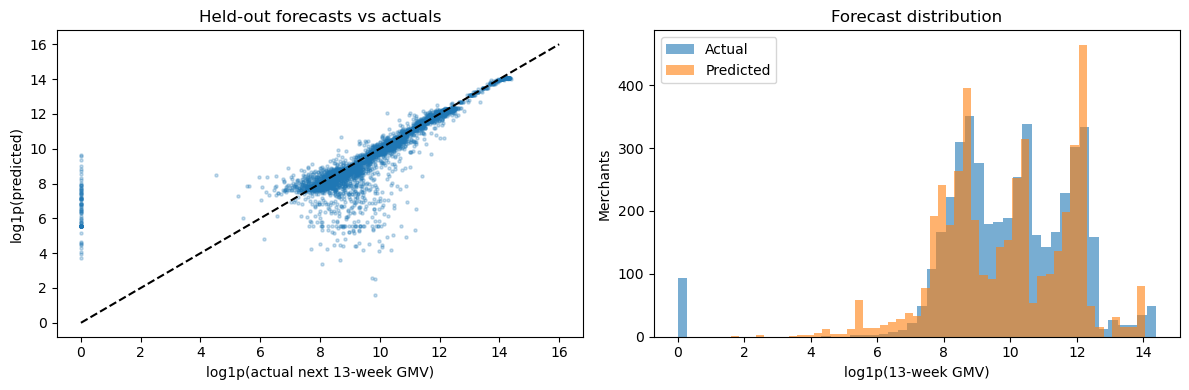

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(np.log1p(valid.target_13w_gmv), np.log1p(valid.model_pred), s=5, alpha=.25)
axes[0].plot([0,16],[0,16], ls='--', color='black')
axes[0].set(xlabel='log1p(actual next 13-week GMV)', ylabel='log1p(predicted)', title='Held-out forecasts vs actuals')
axes[1].hist(np.log1p(valid.target_13w_gmv), bins=50, alpha=.6, label='Actual')
axes[1].hist(np.log1p(valid.model_pred), bins=50, alpha=.6, label='Predicted')
axes[1].set(xlabel='log1p(13-week GMV)', ylabel='Merchants', title='Forecast distribution')
axes[1].legend(); plt.tight_layout(); plt.show()
valid[['merchant_abn','week','target_13w_gmv','model_pred','baseline_pred']].to_csv(
    OUT_DIR / 'forecast_backtest_predictions.csv', index=False)

## 8. Refit using all known history, then forecast the next 13 weeks

Once validation is complete, train on additional labelled cutoffs whose 13-week outcomes end by the latest complete week. Predict at the **latest complete week**, for which the next 13 weeks are not in the dataset. The training sample excludes the prediction cutoff itself.

In [9]:
final_cutoffs = all_weeks[12 : len(all_weeks)-HORIZON : 4]
# Include the most recent fully-labelled cutoff, even if not on the 4-week grid.
latest_labelled_cutoff = all_weeks[-(HORIZON+1)]
final_cutoffs = sorted(set(final_cutoffs).union({latest_labelled_cutoff}))
final_train = panel.loc[panel.week.isin(final_cutoffs) & panel.target_13w_gmv.notna()].copy()
assert final_train.week.max() + pd.Timedelta(weeks=HORIZON) <= last_complete_week
final_model = make_model()
final_model.fit(final_train[FEATURES].replace([np.inf,-np.inf], np.nan),
                np.log1p(final_train.target_13w_gmv.clip(lower=0)))
latest = panel.loc[panel.week == last_complete_week].copy()
latest['predicted_3m_revenue'] = np.expm1(
    final_model.predict(latest[FEATURES].replace([np.inf,-np.inf], np.nan))
).clip(min=0)
latest['baseline_3m_gmv'] = latest['gmv_sum_13'].clip(lower=0)
print('Forecast origin:', last_complete_week.date())
print('Forecast covers the NEXT 13 weeks (not observed yet).')
print(latest[['merchant_abn','predicted_3m_revenue','baseline_3m_gmv']].head())

Forecast origin: 2022-10-17
Forecast covers the NEXT 13 weeks (not observed yet).
     merchant_abn  predicted_3m_revenue  baseline_3m_gmv
86    10023283211         135083.388872    119862.343750
173   10142254217          23304.660541     21520.529297
260   10165489824           2510.945090      9089.492188
347   10187291046           7214.925144      6502.276855
434   10192359162          37227.714143     39182.191406


## 9. Export merchant predictions and validate coverage

Export one row per merchant. If your ranking dataset contains merchants not found in the weekly transaction panel, include them with a missing prediction and review the mismatch; **do not silently replace missing forecasts with zero**.

In [10]:
predictions = latest[['merchant_abn','predicted_3m_revenue','baseline_3m_gmv']].copy()
predictions['forecast_origin_week'] = last_complete_week
features_path = OUT_DIR / 'merchant_features.parquet'
if features_path.exists():
    ids = pd.read_parquet(features_path, columns=['merchant_abn'])
    assert ids.merchant_abn.is_unique
    predictions = ids.merge(predictions, on='merchant_abn', how='left', validate='one_to_one')
    print('Merchant features rows:',len(ids),'| unmatched forecasts:',predictions.predicted_3m_revenue.isna().sum())
assert predictions.merchant_abn.is_unique
assert predictions.predicted_3m_revenue.dropna().ge(0).all()
output = OUT_DIR / 'predicted_3m_revenue.parquet'
predictions.to_parquet(output, index=False)
predictions.to_csv(OUT_DIR / 'predicted_3m_revenue.csv', index=False)
print('Saved:', output)
print(predictions.predicted_3m_revenue.describe(percentiles=[.5,.9,.99]).round(2))

Merchant features rows: 4422 | unmatched forecasts: 0
Saved: /Users/amyliu/Desktop/MAST30034_Project_2/data/curated/merchant_features/predicted_3m_revenue.parquet
count       4422.00
mean       92022.41
std       187786.04
min           12.21
50%        26179.94
90%       221980.40
99%      1209952.77
max      1209952.77
Name: predicted_3m_revenue, dtype: float64


In [11]:
from pathlib import Path

# Works when running from the project root or notebooks/ folder
ROOT = Path.cwd().resolve()

if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent

if not (ROOT / "data").is_dir():
    raise FileNotFoundError(
        "Cannot find the project's data/ folder."
    )

import pandas as pd
import numpy as np

# Paths relative to the project root
features_path = ROOT / "data" / "merchant_features.parquet"

forecast_path = (
    ROOT / "data" / "curated"
    / "merchant_features"
    / "predicted_3m_revenue.parquet"
)

# Load datasets
features = pd.read_parquet(features_path)
forecasts = pd.read_parquet(forecast_path)

# Standardise merchant IDs
features["merchant_abn"] = features["merchant_abn"].astype(str)
forecasts["merchant_abn"] = forecasts["merchant_abn"].astype(str)

# Ensure one row per merchant
assert features["merchant_abn"].is_unique
assert forecasts["merchant_abn"].is_unique

# Remove any existing forecast column
features = features.drop(
    columns=["predicted_3m_revenue"],
    errors="ignore"
)

# Merge forecasts into merchant features
updated_features = features.merge(
    forecasts[["merchant_abn", "predicted_3m_revenue"]],
    on="merchant_abn",
    how="left",
    validate="one_to_one"
)

# Validate the merge
assert len(updated_features) == len(features)

missing = updated_features["predicted_3m_revenue"].isna().sum()

print("Total merchants:", len(updated_features))
print("Missing predictions:", missing)

# Save only if all merchants have predictions
if missing == 0:
    updated_features.to_parquet(features_path, index=False)
    print("Successfully updated merchant_features.parquet!")
else:
    print("Not saved: some merchants are missing forecasts.")
    display(
        updated_features.loc[
            updated_features["predicted_3m_revenue"].isna(),
            ["merchant_abn"]
        ].head(20)
    )

Total merchants: 4379
Missing predictions: 0
Successfully updated merchant_features.parquet!


## 10. Integrate into ranking (run separately, once)

In `merchant_ranking.ipynb`, load the original merchant features and merge the **new forecast** before scoring. Avoid overwriting `merchant_features.parquet` repeatedly: it can create duplicated/suffixed prediction columns.

```python
features = pd.read_parquet(ROOT / 'data/curated/merchant_features/merchant_features.parquet')
pred = pd.read_parquet(ROOT / 'data/curated/merchant_features/predicted_3m_revenue.parquet')
features = features.drop(columns=['predicted_3m_revenue'], errors='ignore')
merchants = features.merge(pred[['merchant_abn','predicted_3m_revenue']],
                           on='merchant_abn', how='left', validate='one_to_one')
assert merchants.predicted_3m_revenue.notna().all(), 'Investigate missing predictions'
```

Then rerun ranking, sensitivity analysis, and segmentation. **Never merge new predictions into an already-ranked table without recalculating its scores.**

### Presentation limitations
- Forecast horizon = 13 weeks, an approximation to three calendar months.
- The model predicts **merchant GMV**, not BNPL fees, actual onboarding uplift, or profit.
- A single chronological backtest is a first check; additional rolling-origin tests are recommended.
- Feature correlations and seasonal shifts can affect stability. Verify improvement against the baseline before claiming superiority.
- If the historical dataset contains periods after the intended business decision date, explicitly state that the model is a retrospective forecasting exercise rather than a historically available prediction.